In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [2]:


# 1. Load the ARFF file using SciPy
# data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")
data = pd.read_csv("df_final.csv")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,SP,38.71,8.72,500.0,1976.0,b'utilidades_domesticas',SP,2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,SP,32.70,12.80,200.0,2560.0,b'cama_mesa_banho',SP,2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,SP,29.75,11.85,250.0,4800.0,b'cama_mesa_banho',SP,2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
3,SP,118.86,8.96,525.0,4368.0,b'beleza_saude',SP,2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0
4,SP,88.90,8.91,250.0,3960.0,b'beleza_saude',SP,2018.0,138.861099,100.485,...,15.758284,15.924686,14.586934,0.0,0.0,0.0,13.817425,15249.215838,421109.470293,4.0


<Axes: xlabel='principal_category_by_price'>

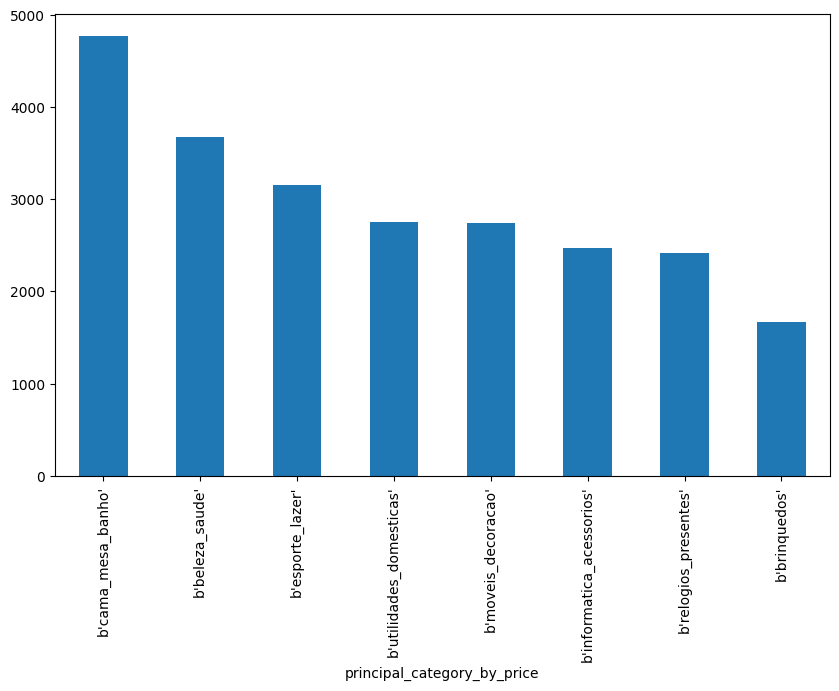

In [3]:
df["principal_category_by_price"].value_counts().plot(kind='bar', figsize=(10, 6))      

In [4]:
# df_muestra = df.sample(frac=0.05, random_state=42)
# print(f"Filas originales: {len(df)}")
# print(f"Filas en la muestra: {len(df_muestra)}")
# df_muestra.to_csv('df_muestra.csv', index=False, encoding='utf-8')


In [5]:
#Correccion de tipos de datos
df['customer_state']=df['customer_state'].astype('category')
df["principal_category_by_price"] = df["principal_category_by_price"].astype('category')
df["principal_seller_state_by_price"] = df["principal_seller_state_by_price"].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23667 entries, 0 to 23666
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    23667 non-null  category
 1   total_payment_value               23667 non-null  float64 
 2   total_freight                     23667 non-null  float64 
 3   total_weight_g                    23667 non-null  float64 
 4   total_volume_cm3                  23667 non-null  float64 
 5   principal_category_by_price       23667 non-null  category
 6   principal_seller_state_by_price   23667 non-null  category
 7   purchase_year                     23667 non-null  float64 
 8   facturacion_promedio_t1           23667 non-null  float64 
 9   facturacion_mediana_t1            23667 non-null  float64 
 10  facturacion_std_t1                23667 non-null  float64 
 11  facturacion_total_7d_avg          23667 non-null  floa

array([[<Axes: title={'center': 'total_payment_value'}>,
        <Axes: title={'center': 'total_freight'}>,
        <Axes: title={'center': 'total_weight_g'}>,
        <Axes: title={'center': 'total_volume_cm3'}>],
       [<Axes: title={'center': 'purchase_year'}>,
        <Axes: title={'center': 'facturacion_promedio_t1'}>,
        <Axes: title={'center': 'facturacion_mediana_t1'}>,
        <Axes: title={'center': 'facturacion_std_t1'}>],
       [<Axes: title={'center': 'facturacion_total_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_t2'}>,
        <Axes: title={'center': 'dias_entrega_promedio_prev_month'}>],
       [<Axes: title={'center': 'es_post_domingo_festivo'}>,
        <Axes: title={'center': 'es_diciembre'}>,
        <Axes: title={'center': 'es_fin_de_semana_extendido'}>,
        <Axes: title={'center': 'distancia_km'}>],
       [<Axes: title={'center': 'distancia_total_t1'}>,
        <Axes

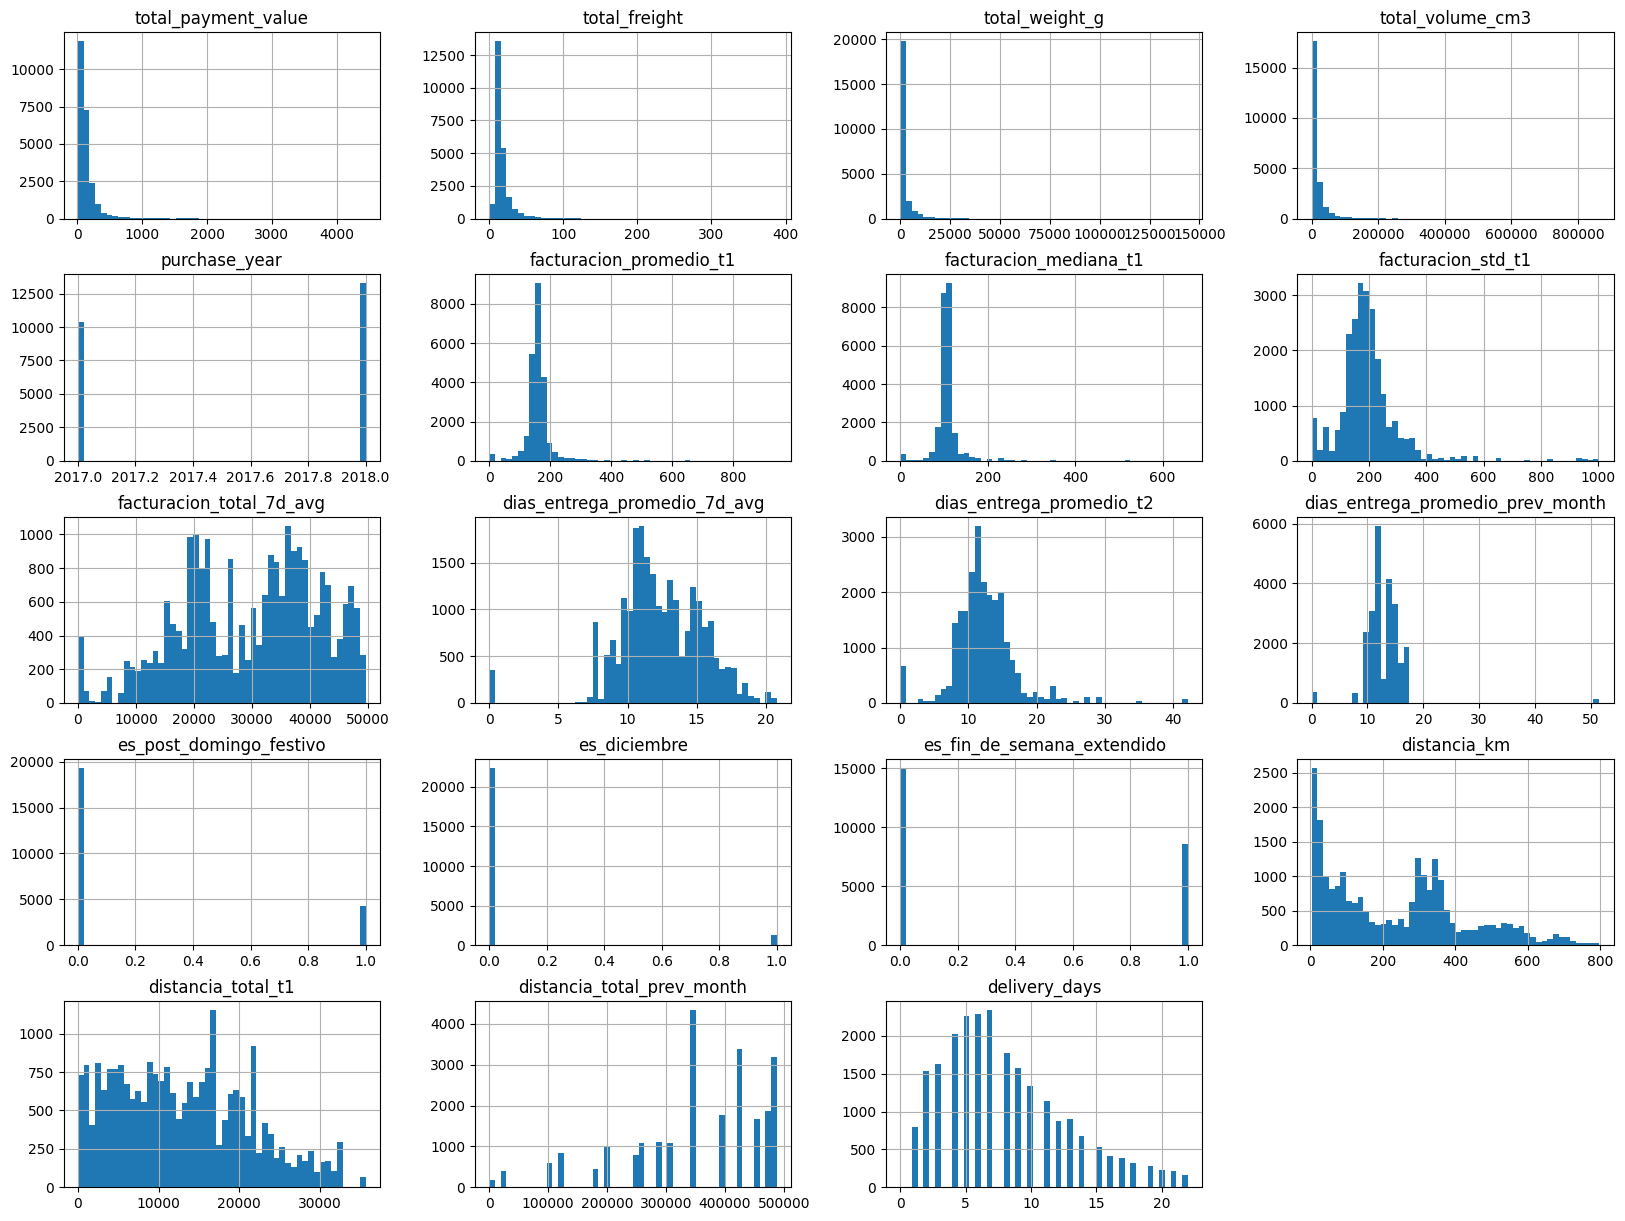

In [6]:
df.hist(bins=50, figsize=(20,15))

In [7]:
df["purchase_year"] = df["purchase_year"].astype(int)
flags = ["es_post_domingo_festivo", "es_diciembre", "es_fin_de_semana_extendido"]
df[flags] = df[flags].astype(int)

cat_cols = ["customer_state", "principal_category_by_price", "principal_seller_state_by_price"]
for col in cat_cols:
    df[col] = (
        df[col].astype(object)
        .map(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)
        .astype("category")
    )

data = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
print(data.shape)
print([c for c in data.columns if "b'" in c])  # debe imprimir []
print(data.head())

(23667, 33)
["principal_category_by_price_b'beleza_saude'", "principal_category_by_price_b'brinquedos'", "principal_category_by_price_b'cama_mesa_banho'", "principal_category_by_price_b'esporte_lazer'", "principal_category_by_price_b'informatica_acessorios'", "principal_category_by_price_b'moveis_decoracao'", "principal_category_by_price_b'relogios_presentes'", "principal_category_by_price_b'utilidades_domesticas'"]
   total_payment_value  total_freight  total_weight_g  total_volume_cm3  \
0                38.71           8.72           500.0            1976.0   
1                32.70          12.80           200.0            2560.0   
2                29.75          11.85           250.0            4800.0   
3               118.86           8.96           525.0            4368.0   
4                88.90           8.91           250.0            3960.0   

   purchase_year  facturacion_promedio_t1  facturacion_mediana_t1  \
0           2017               111.890769                  9

In [8]:
#Se separa variables predictoras y objetivo
objetivo = 'delivery_days'
X = data.drop(objetivo, axis=1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23667 entries, 0 to 23666
Data columns (total 32 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   total_payment_value                                    23667 non-null  float64
 1   total_freight                                          23667 non-null  float64
 2   total_weight_g                                         23667 non-null  float64
 3   total_volume_cm3                                       23667 non-null  float64
 4   purchase_year                                          23667 non-null  int64  
 5   facturacion_promedio_t1                                23667 non-null  float64
 6   facturacion_mediana_t1                                 23667 non-null  float64
 7   facturacion_std_t1                                     23667 non-null  float64
 8   facturacion_total_7d_avg                      

In [9]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn import tree

# 1. Creas la función
def wmape_func(y_real, y_pred):
    return np.sum(np.abs(y_real - y_pred)) / np.sum(np.abs(y_real))

# 2. La conviertes en un métrica compatible con Scikit-Learn
# Le ponemos greater_is_better=False para que siga la misma lógica negativa de tus otras métricas
wmape_scorer = make_scorer(wmape_func, greater_is_better=False)

# 3. Lo agregas a tu diccionario de métricas
scoring = {
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
    'neg_wmape': wmape_scorer, # <--- Tu nueva métrica
    # 'neg_mean_absolute_percentage_error':  'neg_mean_absolute_percentage_error'
}

cv = 10


In [ ]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate

modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=1000, max_depth=2, random_state=42)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)


# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_dt = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_dt[2:] = resultados_promedio_dt[2:].abs()

print(resultados_promedio_dt)



fit_time                              0.059287
score_time                            0.004976
test_neg_mean_absolute_error          3.246244
train_neg_mean_absolute_error         3.242894
test_neg_mean_squared_error          17.233951
train_neg_mean_squared_error         17.204435
test_neg_root_mean_squared_error      4.150812
train_neg_root_mean_squared_error     4.147816
test_neg_wmape                        0.407058
train_neg_wmape                       0.406599
dtype: float64


: 

In [11]:
#Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(
    n_estimators=100, max_samples=0.8, criterion='squared_error', min_samples_leaf=100, max_depth=None, max_features=0.8, random_state=42, n_jobs=-1
)
scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)

# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_rf = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_rf[2:] = resultados_promedio_rf[2:].abs()

print(resultados_promedio_rf)



fit_time                              0.488345
score_time                            0.031680
test_neg_mean_absolute_error          2.962306
train_neg_mean_absolute_error         2.898436
test_neg_mean_squared_error          14.793795
train_neg_mean_squared_error         14.170046
test_neg_root_mean_squared_error      3.845840
train_neg_root_mean_squared_error     3.764308
test_neg_wmape                        0.371460
train_neg_wmape                       0.363411
dtype: float64


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Solo las variables continuas (dummies y banderas ya están en 0/1)
variables_continuas = [
    'total_payment_value', 'total_freight', 'total_weight_g', 'total_volume_cm3',
    'purchase_year', 'facturacion_promedio_t1', 'facturacion_mediana_t1',
    'facturacion_std_t1', 'facturacion_total_7d_avg',
    'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
    'dias_entrega_promedio_prev_month', 'distancia_km',
    'distancia_total_t1', 'distancia_total_prev_month'
]

X_esc = X.copy()
X_esc[variables_continuas] = MinMaxScaler().fit_transform(X[variables_continuas])

X_esc.describe().loc[["min", "max"]]   # verificación: todo entre 0 y 1

,total_payment_value,total_freight,total_weight_g,total_volume_cm3,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,facturacion_std_t1,facturacion_total_7d_avg,dias_entrega_promedio_7d_avg,...,principal_category_by_price_b'cama_mesa_banho',principal_category_by_price_b'esporte_lazer',principal_category_by_price_b'informatica_acessorios',principal_category_by_price_b'moveis_decoracao',principal_category_by_price_b'relogios_presentes',principal_category_by_price_b'utilidades_domesticas',principal_seller_state_by_price_MG,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [13]:
#Red neuronal
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(activation="relu", hidden_layer_sizes=(40), learning_rate_init=0.001, momentum= 0.02, max_iter=1800, random_state=42, verbose=False)

scores = cross_validate(model_rn, X_esc, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_rn = pd.DataFrame(scores)
# print(scores_rn)

resultados_promedio_rn = scores_rn.mean()
resultados_promedio_rn[2:] = resultados_promedio_rn[2:].abs()
print(resultados_promedio_rn)

#2 

fit_time                             13.376969
score_time                            0.004156
test_neg_mean_absolute_error          2.991778
train_neg_mean_absolute_error         2.911480
test_neg_mean_squared_error          15.347901
train_neg_mean_squared_error         14.503118
test_neg_root_mean_squared_error      3.917430
train_neg_root_mean_squared_error     3.808273
test_neg_wmape                        0.375132
train_neg_wmape                       0.365047
dtype: float64


In [14]:
#XGBoost
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.9, random_state=42, n_jobs=-1
)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_xgb = pd.DataFrame(scores)

resultados_promedio_xgb = scores_xgb.mean()
resultados_promedio_xgb[2:] = resultados_promedio_xgb[2:].abs()
print(resultados_promedio_xgb)

fit_time                              0.444523
score_time                            0.008453
test_neg_mean_absolute_error          2.881388
train_neg_mean_absolute_error         2.767577
test_neg_mean_squared_error          14.176739
train_neg_mean_squared_error         13.044408
test_neg_root_mean_squared_error      3.764799
train_neg_root_mean_squared_error     3.611699
test_neg_wmape                        0.361306
train_neg_wmape                       0.347003
dtype: float64


In [15]:
X.columns

Index(['total_payment_value', 'total_freight', 'total_weight_g',
       'total_volume_cm3', 'purchase_year', 'facturacion_promedio_t1',
       'facturacion_mediana_t1', 'facturacion_std_t1',
       'facturacion_total_7d_avg', 'dias_entrega_promedio_7d_avg',
       'dias_entrega_promedio_t2', 'dias_entrega_promedio_prev_month',
       'es_post_domingo_festivo', 'es_diciembre', 'es_fin_de_semana_extendido',
       'distancia_km', 'distancia_total_t1', 'distancia_total_prev_month',
       'customer_state_RJ', 'customer_state_SP',
       'principal_category_by_price_b'beleza_saude'',
       'principal_category_by_price_b'brinquedos'',
       'principal_category_by_price_b'cama_mesa_banho'',
       'principal_category_by_price_b'esporte_lazer'',
       'principal_category_by_price_b'informatica_acessorios'',
       'principal_category_by_price_b'moveis_decoracao'',
       'principal_category_by_price_b'relogios_presentes'',
       'principal_category_by_price_b'utilidades_domesticas'',
    

                                   Decision Tree  Random Forest    XGBoost  \
fit_time                                0.067822       0.488345   0.444523   
score_time                              0.002833       0.031680   0.008453   
test_neg_mean_absolute_error            3.107045       2.962306   2.881388   
train_neg_mean_absolute_error           3.094207       2.898436   2.767577   
test_neg_mean_squared_error            16.101809      14.793795  14.176739   
train_neg_mean_squared_error           15.981116      14.170046  13.044408   
test_neg_root_mean_squared_error        4.012301       3.845840   3.764799   
train_neg_root_mean_squared_error       3.997634       3.764308   3.611699   
test_neg_wmape                          0.389607       0.371460   0.361306   
train_neg_wmape                         0.387957       0.363411   0.347003   

                                   Red Neuronal  
fit_time                              13.376969  
score_time                             0.

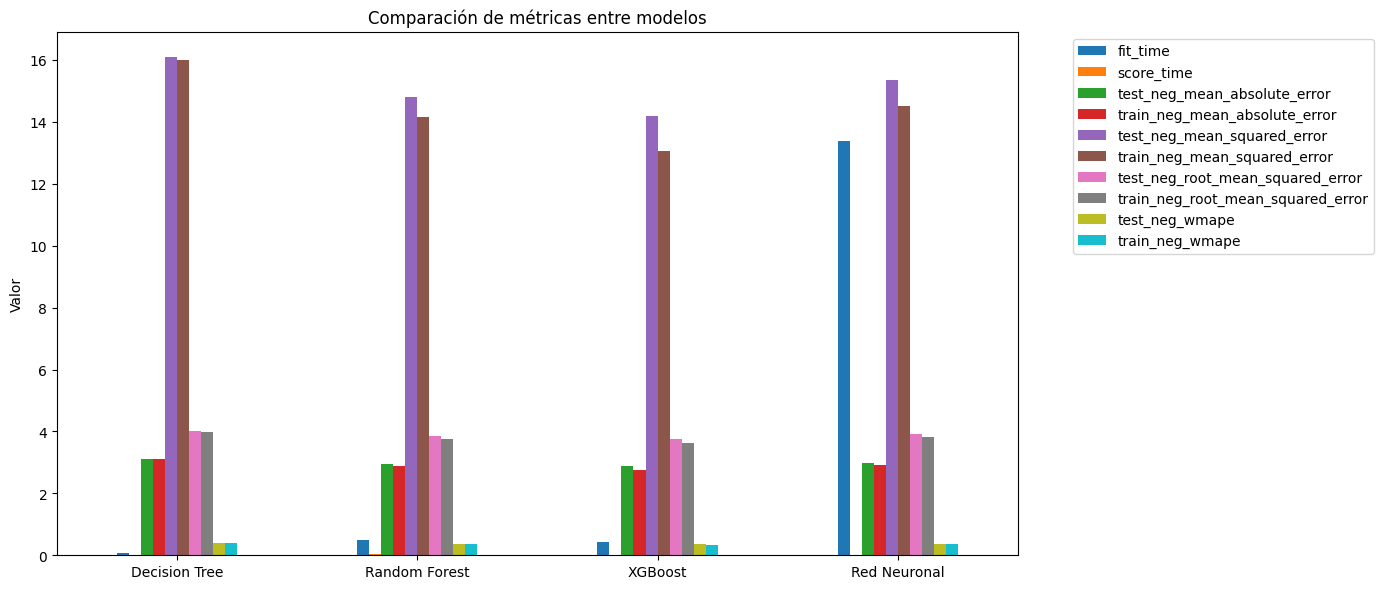

In [16]:
comparacion = pd.DataFrame({
    'Decision Tree': resultados_promedio_dt,
    'Random Forest': resultados_promedio_rf,
    'XGBoost': resultados_promedio_xgb,
    'Red Neuronal': resultados_promedio_rn
})

print(comparacion)

comparacion.T.plot(kind='bar', figsize=(14, 6))
plt.title('Comparación de métricas entre modelos')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
import time
import joblib
import os
import numpy as np

# Entrenamiento final de cada modelo (con todos los datos)
modelTree_final = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=700, max_depth=9, random_state=42).fit(X, Y)

modelRf_final = ensemble.RandomForestRegressor(
    n_estimators=200, max_samples=0.9, criterion='squared_error',
    min_samples_leaf=5, max_depth=10, max_features=0.7, random_state=42, n_jobs=-1
).fit(X, Y)

modelXgb_final = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7,
    colsample_bytree=0.9, random_state=42, n_jobs=-1
).fit(X, Y)

modelRn_final = MLPRegressor(
    activation="relu", hidden_layer_sizes=(40), learning_rate_init=0.001,
    momentum=0.02, max_iter=1800, random_state=42, verbose=False
).fit(X_esc, Y)

In [18]:
modelos = {
    'Decision Tree': modelTree_final,
    'Random Forest': modelRf_final,
    'XGBoost': modelXgb_final,
    'Red Neuronal': modelRn_final
}

tamaños = {}
for nombre, modelo in modelos.items():
    archivo = f'{nombre.replace(" ", "_")}.pkl'
    joblib.dump(modelo, archivo)
    tamaños[nombre] = os.path.getsize(archivo) / 1024  # en KB

for nombre, kb in tamaños.items():
    print(f"{nombre}: {kb:.2f} KB")

Decision Tree: 5.78 KB
Random Forest: 12920.24 KB
XGBoost: 582.11 KB
Red Neuronal: 57.67 KB


In [19]:
import pickle

# Entrenamos el modelo final con todos los datos
model_xgb_final = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.9, random_state=42, n_jobs=-1
)
model_xgb_final.fit(X, Y)

# Guardamos como tupla (modelo, columnas) para que coincida con tu forma de lectura
with open('modelo_xgb.pkl', 'wb') as archivo:
    pickle.dump((model_xgb_final, list(X.columns)), archivo)

print("Modelo guardado como modelo_xgb.pkl")

Modelo guardado como modelo_xgb.pkl


In [20]:
def medir_latencia(modelo, X_sample, n=100, escalado=False):
    datos = X_esc.iloc[[0]] if escalado else X.iloc[[0]]
    tiempos = []
    for _ in range(n):
        inicio = time.time()
        modelo.predict(datos)
        tiempos.append(time.time() - inicio)
    return np.mean(tiempos) * 1000  # ms

print(f"Decision Tree: {medir_latencia(modelTree_final, X):.3f} ms")
print(f"Random Forest: {medir_latencia(modelRf_final, X):.3f} ms")
print(f"XGBoost: {medir_latencia(modelXgb_final, X):.3f} ms")
print(f"Red Neuronal: {medir_latencia(modelRn_final, X_esc, escalado=True):.3f} ms")

Decision Tree: 0.879 ms
Random Forest: 43.984 ms
XGBoost: 3.034 ms
Red Neuronal: 0.860 ms


In [21]:
resumen = pd.DataFrame({
    'Tamaño (KB)': tamaños,
    'Latencia (ms)': {
        'Decision Tree': medir_latencia(modelTree_final, X),
        'Random Forest': medir_latencia(modelRf_final, X),
        'XGBoost': medir_latencia(modelXgb_final, X),
        'Red Neuronal': medir_latencia(modelRn_final, X_esc, escalado=True)
    }
})
resumen = resumen.join(comparacion.T[['test_r2']] if 'test_r2' in comparacion.T.columns else comparacion.T)
print(resumen)

                Tamaño (KB)  Latencia (ms)   fit_time  score_time  \
Decision Tree      5.782227       0.623527   0.067822    0.002833   
Random Forest  12920.235352      44.735086   0.488345    0.031680   
XGBoost          582.114258       2.961495   0.444523    0.008453   
Red Neuronal      57.670898       0.823832  13.376969    0.004156   

               test_neg_mean_absolute_error  train_neg_mean_absolute_error  \
Decision Tree                      3.107045                       3.094207   
Random Forest                      2.962306                       2.898436   
XGBoost                            2.881388                       2.767577   
Red Neuronal                       2.991778                       2.911480   

               test_neg_mean_squared_error  train_neg_mean_squared_error  \
Decision Tree                    16.101809                     15.981116   
Random Forest                    14.793795                     14.170046   
XGBoost                          14